# Chapter 6 — The Reciprocity Model: Iterated PD with TFT
**Modeling Social Behavior** | Smaldino

---

## What This Model Does

This notebook is the capstone model of Chapter 6. It combines everything from the previous
two exercises and adds **reciprocity** through the Tit-for-Tat (TFT) strategy.

The key additions over Exercise 2:
1. **Iterated game** — each pair of neighbors plays `num_iterations` rounds per time step
2. **TFT strategy** — cooperators can now be *smart* (TFT) instead of naïve (ALLC)
3. **TFT switch** — `use_TFT` toggles between running with ALLC or TFT as the cooperative strategy

**The central question:** Can reciprocity allow cooperation to survive even when spatial
assortment is disrupted? How many rounds of interaction does it take for TFT to hold on?

---

## What Changed From Exercise 2

| Component | Exercise 2 | Exercise 3 |
|---|---|---|
| Strategies | ALLC vs ALLD | ALLC vs ALLD (if `use_TFT=False`) or TFT vs ALLD (if `use_TFT=True`) |
| Game duration | 1 round per neighbor | `num_iterations` rounds per neighbor |
| **NEW: TFT payoff** | — | TFT only gets exploited once per defector; ALLC gets exploited every round |
| Randomization | `randomization_prob` | Same |

---

## The Critical Payoff Logic

This is the heart of the model. The number of rounds (`k = num_iterations`) changes how much
defectors can exploit cooperative agents:

**ALLC** (naïve cooperator) vs a defector neighbor — exploited **every round**:
```
V(ALLC) = k × [n_C × (b - c) - n_D × c]
```

**TFT** vs a defector neighbor — exploited only **once** (round 1), then TFT retaliates:
```
V(TFT) = k × [n_C × (b - c)] - n_D × c
```

**ALLD** vs ALLC — exploits ALLC every round:
```
V(ALLD vs ALLC) = k × n_C × b
```

**ALLD** vs TFT — exploits TFT only once (TFT defects back after round 1):
```
V(ALLD vs TFT) = n_C × b
```

The larger `k` is, the bigger the gap between TFT and ALLC against defectors.

---

## Variable Types

- **Global variables** — `b`, `c`, `L`, `init_coop_freq`, `randomization_prob`, `num_iterations`, `use_TFT`
- **Agent variables** — `strategy`, `payoff`
- **Local variables** — temporary values inside functions


## Step 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

np.random.seed(42)


## Step 2 — Global Parameters

Two new global parameters join the previous ones:

- **`num_iterations`** (`k`) — how many rounds each pair of neighbors plays per time step.
  When `k=1`, TFT behaves identically to ALLC (there's no second round for TFT to retaliate).
  As `k` increases, TFT's advantage over ALLC against defectors grows.

- **`use_TFT`** — a boolean switch. When `False`, the cooperative strategy is ALLC (same
  as Exercise 2). When `True`, it becomes TFT. This lets us run controlled comparisons.


In [2]:
# ── GLOBAL VARIABLES ─────────────────────────────────────────────────────

L                  = 31      # Grid side length → 31×31 = 961 agents
b                  = 1.0     # Benefit conferred on a partner by cooperating
c                  = 0.60    # Cost paid per interaction by cooperator/TFT
                             # Higher than previous exercises — TFT handles this better
init_coop_freq     = 0.5     # Starting proportion of cooperative agents

randomization_prob = 0.0     # Probability each agent swaps location each step

# ── NEW GLOBAL VARIABLES ──────────────────────────────────────────────────
num_iterations     = 4       # k: rounds played with each neighbor per time step
                             # k=1 → TFT identical to ALLC
                             # k=4 → TFT exploited only once; ALLC exploited 4 times

use_TFT            = True    # False → cooperative agents are ALLC (Exercise 2 behavior)
                             # True  → cooperative agents are TFT

N = L * L
print(f"Grid: {L}×{L} = {N} agents")
print(f"b={b}, c={c}  |  b/4={b/4:.2f}")
print(f"num_iterations={num_iterations}, use_TFT={use_TFT}")
print(f"randomization_prob={randomization_prob}")
print()
if use_TFT:
    print("TFT mode: cooperative agents are TFT (green)")
    print("  → TFT is exploited by defectors only ONCE per k rounds")
else:
    print("ALLC mode: cooperative agents are ALLC (blue)")
    print("  → ALLC is exploited by defectors EVERY round")


Grid: 31×31 = 961 agents
b=1.0, c=0.6  |  b/4=0.25
num_iterations=4, use_TFT=True
randomization_prob=0.0

TFT mode: cooperative agents are TFT (green)
  → TFT is exploited by defectors only ONCE per k rounds


## Step 3 — Reused Functions From Exercises 1 & 2

`initialize_grid`, `get_neighbors`, `evolve`, and `randomize_locations` are unchanged.
Only `play_game` needs to be updated to handle the iterated game and TFT logic.


In [3]:
# ── REUSED FROM EXERCISES 1 & 2 (unchanged) ──────────────────────────────

def initialize_grid(L, init_coop_freq, seed=None):
    """
    Create the starting population.
    strategy=1 (cooperative agent) with probability init_coop_freq,
    strategy=0 (defector) otherwise. All payoffs start at zero.

    Parameters
    ----------
    L : int                  — global, grid side length
    init_coop_freq : float   — global, starting cooperator proportion
    seed : int or None

    Returns
    -------
    strategy : np.ndarray (L, L) int    — agent variable
    payoff   : np.ndarray (L, L) float  — agent variable, all zeros
    """
    if seed is not None:
        np.random.seed(seed)
    strategy = (np.random.random((L, L)) < init_coop_freq).astype(int)
    payoff   = np.zeros((L, L), dtype=float)
    return strategy, payoff


def get_neighbors(grid):
    """
    Return the four von Neumann neighbors for every cell simultaneously
    using np.roll() with toroidal (wrap-around) boundaries.

    Parameters
    ----------
    grid : np.ndarray (L, L)

    Returns
    -------
    list of 4 arrays [north, south, east, west]
    """
    return [np.roll(grid, -1, axis=0), np.roll(grid,  1, axis=0),
            np.roll(grid, -1, axis=1), np.roll(grid,  1, axis=1)]


def evolve(strategy, payoff):
    """
    Each agent copies the strategy of its highest-payoff neighbor,
    but only if that neighbor's payoff exceeds its own.
    All updates happen simultaneously.

    Parameters
    ----------
    strategy, payoff : np.ndarray (L, L) — agent variables

    Returns
    -------
    new_strategy : np.ndarray (L, L) int — agent variable
    """
    stacked_pay  = np.stack(get_neighbors(payoff),   axis=0)
    stacked_strat= np.stack(get_neighbors(strategy), axis=0)
    best_pay     = stacked_pay.max(axis=0)
    best_idx     = stacked_pay.argmax(axis=0)
    rows = np.arange(strategy.shape[0])[:, None]
    cols = np.arange(strategy.shape[1])[None, :]
    best_strat   = stacked_strat[best_idx, rows, cols]
    mask         = best_pay > payoff
    new_strategy = strategy.copy()
    new_strategy[mask] = best_strat[mask]
    return new_strategy


def randomize_locations(strategy, randomization_prob):
    """
    Before game play, each agent has probability randomization_prob
    of swapping its grid position with a randomly chosen other agent.

    Parameters
    ----------
    strategy           : np.ndarray (L, L) int — agent variable
    randomization_prob : float               — global variable

    Returns
    -------
    new_strategy : np.ndarray (L, L) int — agent variable
    """
    new_strategy = strategy.copy()
    swap_mask    = np.random.random((L, L)) < randomization_prob
    mover_rows, mover_cols = np.where(swap_mask)
    n_movers = len(mover_rows)
    if n_movers == 0:
        return new_strategy
    target_flat = np.random.randint(0, L * L, size=n_movers)
    target_rows = target_flat // L
    target_cols = target_flat  % L
    for i in range(n_movers):
        r1, c1 = mover_rows[i], mover_cols[i]
        r2, c2 = target_rows[i], target_cols[i]
        temp = new_strategy[r1, c1]
        new_strategy[r1, c1] = new_strategy[r2, c2]
        new_strategy[r2, c2] = temp
    return new_strategy


print("Reused functions loaded.")


Reused functions loaded.


## Step 4 — Updated `play_game`: The Iterated Game With TFT Logic

This is the only function that changes substantially from Exercise 2.

The key difference is in how defectors affect cooperative agents:

**When `use_TFT = False` (ALLC mode):**
ALLC cooperates every round with every neighbor, including defectors.
Both cooperative and defection payoffs scale linearly with `num_iterations`.

**When `use_TFT = True` (TFT mode):**
TFT cooperates on round 1, then retaliates against defectors for rounds 2 through k.
- Against a **cooperative neighbor**: full k rounds of mutual cooperation → payoff scales with k
- Against a **defecting neighbor**: TFT pays cost once (round 1) then defects back → payoff does NOT scale with k for defectors

This means a defector exploiting a TFT agent gets only 1 round of benefit regardless of k,
whereas a defector exploiting ALLC gets k rounds of benefit.
As k grows, this difference becomes increasingly decisive.


In [4]:
# ── UPDATED PLAY_GAME: ITERATED GAME WITH TFT ────────────────────────────

def play_game(strategy, b, c, num_iterations, use_TFT):
    """
    Each agent plays the iterated PD with each of its 4 neighbors
    for num_iterations rounds and accumulates total payoff.

    The payoff formulas differ depending on use_TFT:

    ALLC mode (use_TFT=False):
      - Cooperator: k * [n_C*(b-c) - n_D*c]
        (exploited by defectors every round)
      - Defector:   k * n_C*b
        (exploits ALLC every round)

    TFT mode (use_TFT=True):
      - TFT: k*n_C*(b-c) - n_D*c
        (full k rounds of mutual cooperation with C neighbors,
         but only exploited ONCE by each D neighbor — then TFT retaliates)
      - Defector vs TFT: n_C*b
        (only 1 round of benefit from each TFT neighbor, not k)

    Parameters
    ----------
    strategy       : np.ndarray (L, L) int — agent variable
    b, c           : float                 — global variables
    num_iterations : int                   — global variable, rounds per interaction (k)
    use_TFT        : bool                  — global variable, cooperative strategy type

    Returns
    -------
    payoff : np.ndarray (L, L) float — agent variable

    Local variables
    ---------------
    neighbors   : list of 4 neighbor strategy arrays
    n_C         : cooperating neighbor count per agent (0–4)
    n_D         : defecting neighbor count per agent (0–4)
    coop_mask   : boolean mask for cooperative agents (strategy==1)
    defect_mask : boolean mask for defectors (strategy==0)
    k           : shorthand for num_iterations
    """
    neighbors   = get_neighbors(strategy)
    n_C         = sum(neighbors)           # local: cooperating neighbors (0–4)
    n_D         = 4 - n_C                  # local: defecting neighbors (0–4)
    payoff      = np.zeros_like(strategy, dtype=float)
    coop_mask   = (strategy == 1)          # local: True for cooperative agents
    defect_mask = (strategy == 0)          # local: True for defectors
    k           = num_iterations           # local: shorthand

    if not use_TFT:
        # ── ALLC MODE ────────────────────────────────────────────────────
        # Cooperative agents (ALLC): cooperate every round with everyone
        # Payoff scales by k for all interactions
        payoff[coop_mask] = (k * (n_C[coop_mask]   * (b - c)
                                - n_D[coop_mask]   * c))

        # Defectors vs ALLC: exploited every round → scales by k
        payoff[defect_mask] = k * n_C[defect_mask] * b

    else:
        # ── TFT MODE ─────────────────────────────────────────────────────
        # TFT agents: cooperate fully with cooperative neighbors (k rounds),
        # but only get exploited ONCE by defecting neighbors (then retaliate)
        # So the defector cost does NOT multiply by k
        payoff[coop_mask] = (k * n_C[coop_mask]   * (b - c)
                               - n_D[coop_mask]   * c)

        # Defectors vs TFT: only 1 round of exploitation per TFT neighbor
        # (TFT retaliates from round 2 onward, giving defectors nothing)
        payoff[defect_mask] = n_C[defect_mask] * b

    return payoff


# ── SANITY CHECK: k=1, TFT should equal ALLC ─────────────────────────────
strategy_test, _ = initialize_grid(L, 0.5, seed=42)

pay_allc = play_game(strategy_test, b, c, num_iterations=1, use_TFT=False)
pay_tft  = play_game(strategy_test, b, c, num_iterations=1, use_TFT=True)

print("k=1: TFT payoff == ALLC payoff?", np.allclose(pay_allc, pay_tft))
print("  (Expected True: at k=1 TFT has no second round to retaliate)")

# k=4: TFT should differ from ALLC against defectors
pay_allc_k4 = play_game(strategy_test, b, c, num_iterations=4, use_TFT=False)
pay_tft_k4  = play_game(strategy_test, b, c, num_iterations=4, use_TFT=True)

print("\nk=4: TFT payoff == ALLC payoff?", np.allclose(pay_allc_k4, pay_tft_k4))
print("  (Expected False: TFT is less exploited)")

# Show that TFT cooperators do better than ALLC cooperators when defectors are present
allc_coop_payoff = pay_allc_k4[strategy_test == 1].mean()
tft_coop_payoff  = pay_tft_k4[strategy_test == 1].mean()
print(f"\nk=4 mean cooperative agent payoff:")
print(f"  ALLC: {allc_coop_payoff:.3f}")
print(f"  TFT:  {tft_coop_payoff:.3f}")
print(f"  TFT advantage: {tft_coop_payoff - allc_coop_payoff:+.3f}")


k=1: TFT payoff == ALLC payoff? True
  (Expected True: at k=1 TFT has no second round to retaliate)

k=4: TFT payoff == ALLC payoff? False
  (Expected False: TFT is less exploited)

k=4 mean cooperative agent payoff:
  ALLC: -1.500
  TFT:  2.055
  TFT advantage: +3.555


## Step 5 — Time Step and Simulation Runner

`step()` now passes `num_iterations` and `use_TFT` to `play_game`.
Everything else is identical to Exercise 2.


In [5]:
# ── STEP FUNCTION ────────────────────────────────────────────────────────

def step(strategy, b, c, num_iterations, use_TFT, randomization_prob):
    """
    Advance the model by one time step.
    Order: (1) randomize → (2) play iterated game → (3) evolve

    Parameters
    ----------
    strategy, b, c, num_iterations, use_TFT, randomization_prob : global variables

    Returns
    -------
    new_strategy : np.ndarray (L, L) — agent variable
    coop_freq    : float             — cooperative agent frequency after this step
    """
    strategy     = randomize_locations(strategy, randomization_prob)
    payoff       = play_game(strategy, b, c, num_iterations, use_TFT)
    new_strategy = evolve(strategy, payoff)
    return new_strategy, new_strategy.mean()


# ── SIMULATION RUNNER ─────────────────────────────────────────────────────

def run_simulation(L, b, c, init_coop_freq, randomization_prob,
                   num_iterations, use_TFT,
                   n_steps=100, seed=42, save_final_grid=False):
    """
    Run the full model for n_steps time steps and record cooperative frequency.

    Parameters
    ----------
    L, b, c, init_coop_freq, randomization_prob,
    num_iterations, use_TFT : global variables
    n_steps         : int  — number of time steps
    seed            : int  — random seed
    save_final_grid : bool — if True, also return the final strategy grid

    Returns
    -------
    history    : list of float  — cooperative agent frequency at each time step
    final_grid : np.ndarray or None
    """
    strategy, _ = initialize_grid(L, init_coop_freq, seed=seed)
    history     = [strategy.mean()]

    for t in range(1, n_steps + 1):
        strategy, coop_freq = step(strategy, b, c, num_iterations,
                                   use_TFT, randomization_prob)
        history.append(coop_freq)
        if coop_freq == 0.0 or coop_freq == 1.0:
            history += [coop_freq] * (n_steps - t)
            break

    if save_final_grid:
        return history, strategy.copy()
    return history, None


print("Step and simulation functions ready.")


Step and simulation functions ready.


## Step 6 — Visualization Helper

In [6]:
# ── VISUALIZATION ────────────────────────────────────────────────────────

def plot_grid(strategy, use_TFT=True, ax=None, title=None):
    """
    Display the grid.
    Defectors = red; ALLC cooperators = blue; TFT cooperators = green.
    (Matches book convention: red=ALLD, blue=ALLC, green=TFT)
    """
    coop_color = '#2a9d8f' if use_TFT else '#457b9d'  # green for TFT, blue for ALLC
    cmap = mcolors.ListedColormap(['#e63946', coop_color])
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(strategy, cmap=cmap, vmin=0, vmax=1, interpolation='nearest')
    ax.axis('off')
    strategy_name = 'TFT' if use_TFT else 'ALLC'
    freq = strategy.mean()
    if title:
        ax.set_title(title, fontsize=10)
    else:
        ax.set_title(f"{strategy_name} freq: {freq:.2f}", fontsize=10)


## Step 7 — Sanity Check: k=1 Should Equal Exercise 2

When `num_iterations=1`, TFT is functionally identical to ALLC — there's no second round
for TFT to retaliate. We should see the same behavior as Exercise 2.

Use a parameter combination from Exercise 2 where cooperation was failing:
`c=0.60` (well above b/4=0.25). With ALLC, this should collapse. With TFT and k=1, same.


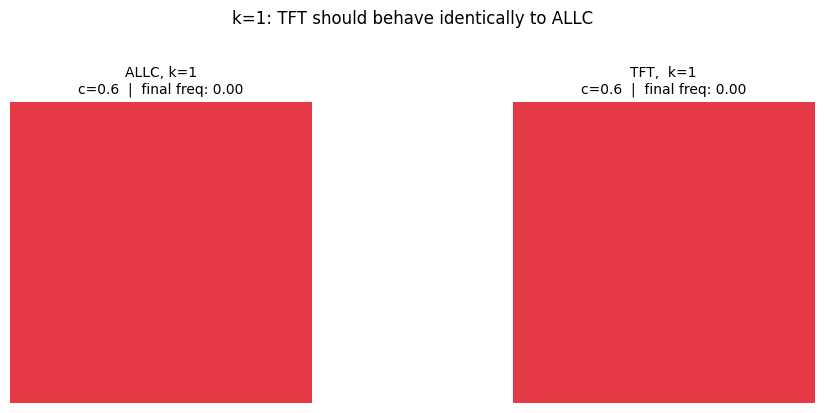

Expected: both collapse — c=0.60 is well above b/4=0.25, k=1 gives TFT no advantage


In [7]:
# ── SANITY CHECK: k=1 → TFT behaves like ALLC ────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, use_tft, label in [(axes[0], False, 'ALLC, k=1'),
                            (axes[1], True,  'TFT,  k=1')]:
    hist, grid = run_simulation(
        L, b, c, init_coop_freq, randomization_prob=0.0,
        num_iterations=1, use_TFT=use_tft,
        n_steps=100, seed=42, save_final_grid=True
    )
    plot_grid(grid, use_TFT=use_tft, ax=ax,
              title=f"{label}\nc={c}  |  final freq: {hist[-1]:.2f}")

fig.suptitle("k=1: TFT should behave identically to ALLC", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Expected: both collapse — c=0.60 is well above b/4=0.25, k=1 gives TFT no advantage")


## Step 8 — The Power of Iterations: TFT With Increasing k

Now keep `c=0.60` (where ALLC always fails) and increase `num_iterations`.
At some point, TFT should gain enough advantage from limiting exploitation to survive.

This recreates the key result from Section 6.6.2 of the book.


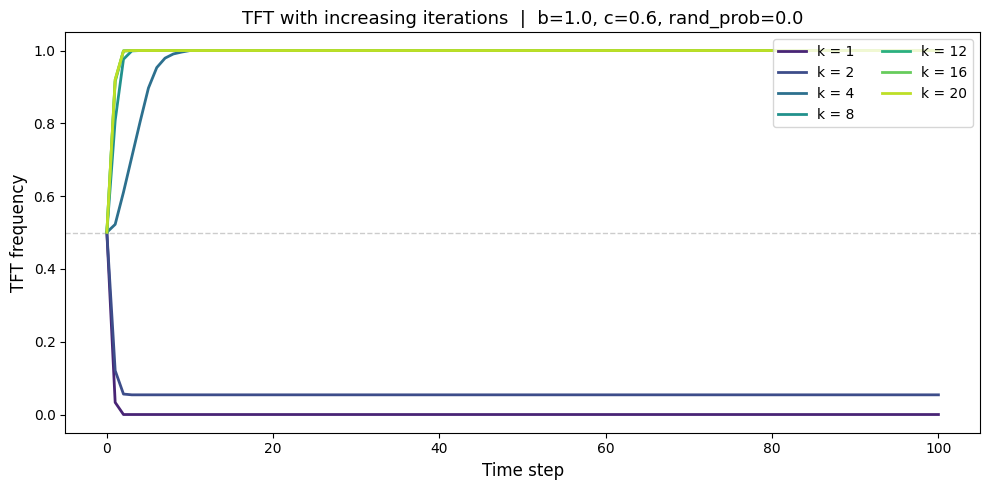

At c=0.6 (b/4=0.25), ALLC always fails.
As k increases, TFT limits exploitation and can dominate.


In [8]:
# ── TFT FREQUENCY vs NUM_ITERATIONS (no randomization) ──────────────────

k_values = [1, 2, 4, 8, 12, 16, 20]
colors   = plt.cm.viridis(np.linspace(0.1, 0.9, len(k_values)))

fig, ax = plt.subplots(figsize=(10, 5))

for k, color in zip(k_values, colors):
    hist, _ = run_simulation(
        L, b, c, init_coop_freq, randomization_prob=0.0,
        num_iterations=k, use_TFT=True,
        n_steps=100, seed=42
    )
    ax.plot(hist, color=color, linewidth=2, label=f'k = {k}')

ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, alpha=0.4)
ax.set_xlabel("Time step", fontsize=12)
ax.set_ylabel("TFT frequency", fontsize=12)
ax.set_title(f"TFT with increasing iterations  |  b={b}, c={c}, rand_prob=0.0",
             fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

print(f"At c={c} (b/4={b/4}), ALLC always fails.")
print("As k increases, TFT limits exploitation and can dominate.")


## Step 9 — Recreating Figure 6.8: TFT Frequency vs Iterations (Two Randomization Levels)

Figure 6.8 from the book shows TFT frequency at t=100 as a function of `num_iterations`,
for several cost values, at **zero randomization** (left) and **full randomization** (right).

The result: TFT succeeds with fewer iterations when spatial assortment helps it (left panel).
With full randomization (right), TFT needs more iterations to build enough temporal assortment
to survive — but it still can, unlike ALLC.

> ⚠️ **This cell takes several minutes.** Reduce `n_runs` to speed it up.


Running 3200 simulations...
Done.


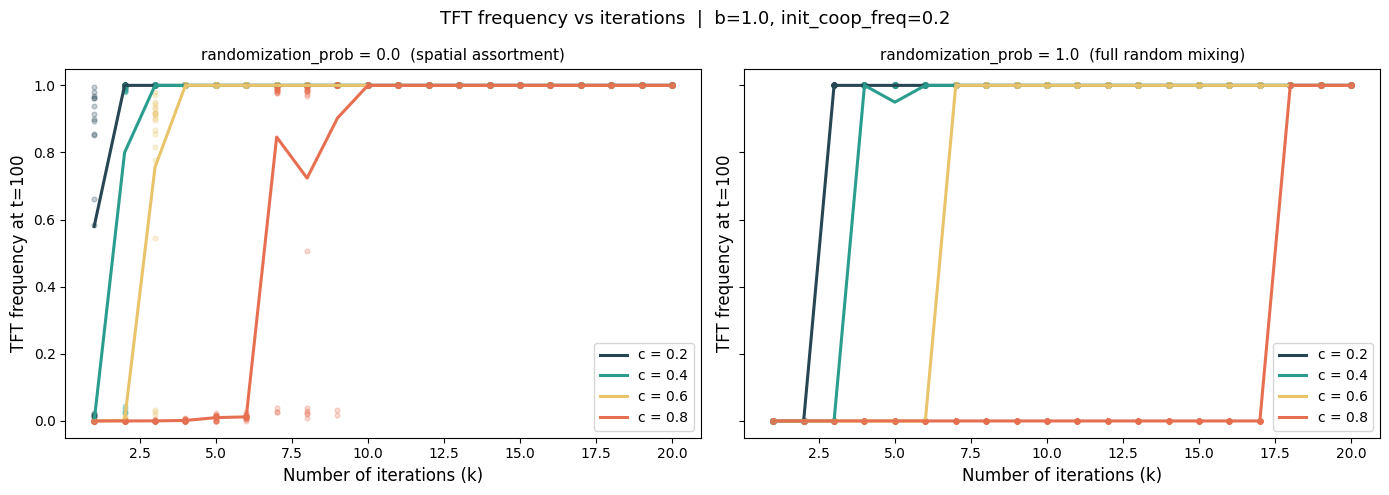

In [9]:
# ── FIGURE 6.8 RECREATION ────────────────────────────────────────────────

k_values_sweep = list(range(1, 21))         # k from 1 to 20
c_values_sweep = [0.2, 0.4, 0.6, 0.8]      # four cost values (book's experiment values)
rand_probs     = [0.0, 1.0]                 # left panel (rigid) vs right panel (full mixing)
n_runs         = 20
n_steps_sweep  = 100
init_coop_invasion = 0.2                    # book uses 20% initial cooperators

# Store results: [rand_idx, c_idx, k_idx, run]
results = np.zeros((2, len(c_values_sweep), len(k_values_sweep), n_runs))

total = 2 * len(c_values_sweep) * len(k_values_sweep) * n_runs
print(f"Running {total} simulations...")

for ri, r_prob in enumerate(rand_probs):
    for ci, c_val in enumerate(c_values_sweep):
        for ki, k in enumerate(k_values_sweep):
            for run in range(n_runs):
                hist, _ = run_simulation(
                    L, b, c_val, init_coop_invasion, r_prob,
                    num_iterations=k, use_TFT=True,
                    n_steps=n_steps_sweep,
                    seed=run * 1000 + ri * 100 + ci * 20 + ki
                )
                results[ri, ci, ki, run] = hist[-1]

print("Done.")

# ── PLOT ──────────────────────────────────────────────────────────────────
c_colors = ['#264653', '#2a9d8f', '#e9c46a', '#e76f51']
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
panel_titles = ['randomization_prob = 0.0  (spatial assortment)',
                'randomization_prob = 1.0  (full random mixing)']

for ri, (ax, title) in enumerate(zip(axes, panel_titles)):
    for ci, (c_val, color) in enumerate(zip(c_values_sweep, c_colors)):
        # Individual run dots
        for run in range(n_runs):
            ax.scatter(k_values_sweep, results[ri, ci, :, run],
                       color=color, alpha=0.25, s=12)
        # Mean line
        ax.plot(k_values_sweep, results[ri, ci, :, :].mean(axis=1),
                color=color, linewidth=2.2, label=f'c = {c_val}')

    ax.set_xlabel("Number of iterations (k)", fontsize=12)
    ax.set_ylabel("TFT frequency at t=100", fontsize=12)
    ax.set_title(title, fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=10)

fig.suptitle(f"TFT frequency vs iterations  |  b={b}, init_coop_freq={init_coop_invasion}",
             fontsize=13)
plt.tight_layout()
plt.show()


## Step 10 — TFT vs ALLC: Head-to-Head Under Randomization

Now test the key claim from the book: TFT can survive levels of randomization that
completely destroy ALLC.

Fix `num_iterations=4` and `c=0.20` (so ALLC can survive at low randomization),
then sweep `randomization_prob` and compare the two cooperative strategies.


Running comparison: ALLC vs TFT  |  k=4, c=0.2
21 randomization values × 15 runs × 2 strategies = 630 simulations...
Done.


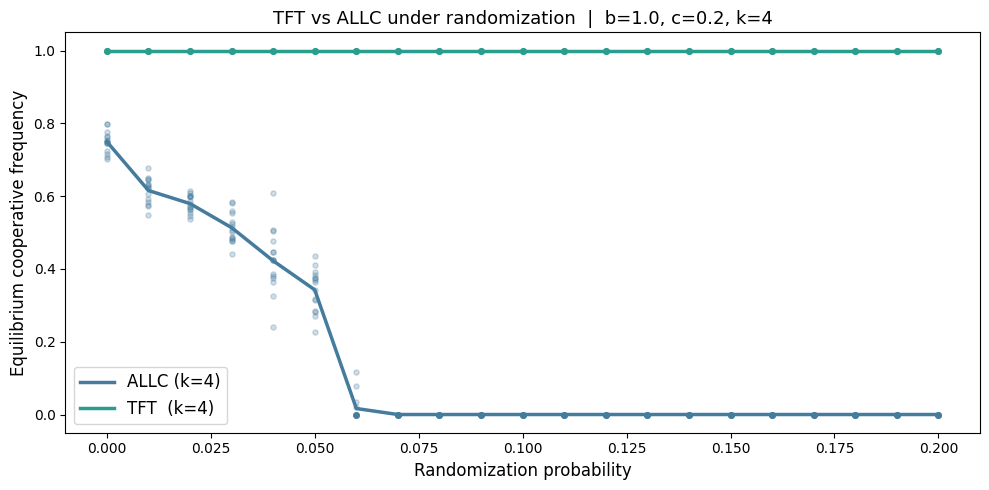

TFT (green) should tolerate higher randomization than ALLC (blue)
Both eventually fail, but TFT holds on at levels where ALLC has already collapsed.


In [10]:
# ── TFT vs ALLC UNDER RANDOMIZATION ──────────────────────────────────────

r_values  = np.arange(0.0, 0.205, 0.01)
n_runs    = 15
k_compare = 4
c_compare = 0.20

results_allc = np.zeros((len(r_values), n_runs))
results_tft  = np.zeros((len(r_values), n_runs))

print(f"Running comparison: ALLC vs TFT  |  k={k_compare}, c={c_compare}")
print(f"{len(r_values)} randomization values × {n_runs} runs × 2 strategies = "
      f"{len(r_values)*n_runs*2} simulations...")

for i, r_prob in enumerate(r_values):
    for run in range(n_runs):
        seed = run * 300 + i

        hist_allc, _ = run_simulation(
            L, b, c_compare, init_coop_freq, r_prob,
            num_iterations=k_compare, use_TFT=False,
            n_steps=200, seed=seed
        )
        results_allc[i, run] = hist_allc[-1]

        hist_tft, _ = run_simulation(
            L, b, c_compare, init_coop_freq, r_prob,
            num_iterations=k_compare, use_TFT=True,
            n_steps=200, seed=seed
        )
        results_tft[i, run] = hist_tft[-1]

print("Done.")

# ── PLOT ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# ALLC
for run in range(n_runs):
    ax.scatter(r_values, results_allc[:, run],
               color='#457b9d', alpha=0.25, s=14)
ax.plot(r_values, results_allc.mean(axis=1),
        color='#457b9d', linewidth=2.5, label=f'ALLC (k={k_compare})')

# TFT
for run in range(n_runs):
    ax.scatter(r_values, results_tft[:, run],
               color='#2a9d8f', alpha=0.25, s=14)
ax.plot(r_values, results_tft.mean(axis=1),
        color='#2a9d8f', linewidth=2.5, label=f'TFT  (k={k_compare})')

ax.set_xlabel("Randomization probability", fontsize=12)
ax.set_ylabel("Equilibrium cooperative frequency", fontsize=12)
ax.set_title(f"TFT vs ALLC under randomization  |  b={b}, c={c_compare}, k={k_compare}",
             fontsize=13)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print("TFT (green) should tolerate higher randomization than ALLC (blue)")
print("Both eventually fail, but TFT holds on at levels where ALLC has already collapsed.")


## Step 11 — Spatial Grids: ALLC vs TFT at High Cost and Randomization

Look at the actual grid at equilibrium for a challenging parameter set:
`c=0.60` (high cost) and `randomization_prob=0.09` (disrupted assortment), `k=4`.

ALLC should collapse. TFT should partially survive.


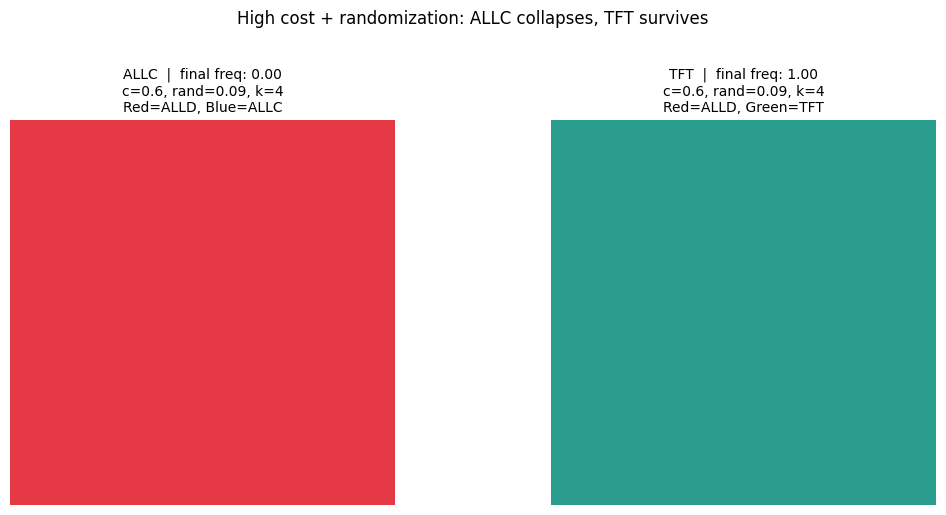

In [11]:
# ── SPATIAL GRIDS: ALLC vs TFT ───────────────────────────────────────────

c_hard    = 0.60
r_hard    = 0.09
k_hard    = 4

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for ax, use_tft, label in [(axes[0], False, 'ALLC'),
                            (axes[1], True,  'TFT')]:
    hist, grid = run_simulation(
        L, b, c_hard, init_coop_freq, r_hard,
        num_iterations=k_hard, use_TFT=use_tft,
        n_steps=200, seed=42, save_final_grid=True
    )
    color_label = 'Green=TFT' if use_tft else 'Blue=ALLC'
    plot_grid(grid, use_TFT=use_tft, ax=ax,
              title=f"{label}  |  final freq: {hist[-1]:.2f}\n"
                    f"c={c_hard}, rand={r_hard}, k={k_hard}\n"
                    f"Red=ALLD, {color_label}")

fig.suptitle("High cost + randomization: ALLC collapses, TFT survives",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()


## Step 12 — Reflection

### What the Model Shows

The three exercises together tell a complete story about the evolution of cooperation:

| Model | Mechanism | Cooperation survives when... |
|---|---|---|
| Exercise 1 | Spatial structure | Cost below b/4 AND network is rigid |
| Exercise 2 | Spatial structure + randomization | Same, but even small mobility destroys it |
| Exercise 3 | Reciprocity (TFT) | Interactions long enough that k×w×b > c |

TFT survives in two ways simultaneously:
- **Spatially** (when `rand_prob` is low): same cluster protection as Exercise 1
- **Temporally** (when `rand_prob` is high): repeated encounters with the same TFT agents
  create *de facto* assortment even without spatial structure — just as Hamilton's Rule predicts

### Questions to Think About

1. **The k=1 sanity check:** At k=1, TFT and ALLC are identical. At exactly what value of k
   does TFT start to outperform ALLC against defectors? Can you work out from the payoff
   formulas why that value makes sense?

2. **Figure 6.8 (left vs right panel):** Comparing the two panels, TFT needs fewer iterations
   to succeed when there's spatial assortment. Why? What is spatial structure giving TFT that
   it doesn't have under full randomization?

3. **The head-to-head comparison (Step 10):** Both ALLC and TFT eventually fail at high enough
   randomization. But TFT's collapse happens at a higher threshold. What is TFT doing
   differently that pushes this threshold higher?

4. **Connecting back to Hamilton's Rule:** The condition for TFT to resist invasion is `wb > c`,
   where `w` is the probability of continuing the interaction. How does `num_iterations` in
   this model relate to `w` from the theory? Are they the same thing, or different?

5. **The limits of the model:** TFT still uses a pure strategy — it never makes mistakes, never
   misidentifies a partner, never forgives a defector who accidentally cooperated. In real life,
   what would these complications do to TFT's performance? Would TFT still dominate?

